## imports

In [20]:
import pandas as pd
from torch_geometric.datasets import QM9
import torch
from rdkit import Chem
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import load
from sklearn.preprocessing import MinMaxScaler, StandardScaler

## helper functions

In [15]:
def canonicalize_smiles(smiles: str) -> str | None:
    """
    Converts a SMILES string to its canonical form using RDKit.

    Args:
        smiles: The input SMILES string.

    Returns:
        The canonical SMILES string, or None if the input is invalid.
    """
    # Add this check at the beginning to handle None inputs gracefully
    if smiles is None:
        return None
    
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except Exception:
        return None


def is_canonical(smiles: str) -> bool:
    """
    Checks if a SMILES string is canonical using RDKit.

    Args:
        smiles: The input SMILES string to check.

    Returns:
        True if the SMILES is canonical, False otherwise.
        Returns False if the SMILES is invalid.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # The input SMILES is invalid
        return False
    
    # Generate the canonical SMILES from the molecule object
    canonical_smiles = Chem.MolToSmiles(mol)
    
    # Compare the input with the canonical version
    return smiles == canonical_smiles


def remove_stereochemistry(smiles: str) -> str | None:
    """
    Parses a SMILES string and returns its canonical, achiral form.
    Includes error handling to return None if any step fails.
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        # This single call generates the canonical SMILES of the achiral graph
        return Chem.MolToSmiles(mol, isomericSmiles=False)
    except Exception:
        return None

## HL-gaps data

In [16]:
try:
    df_gap = pd.read_pickle("../data/processed/gap_smile.pkl")
except FileNotFoundError:
    print("Error: '../data/processed/gap_smile.pkl' not found.")
    exit()
df_gap['canonicalSMILE'] = df_gap['SMILE'].apply(canonicalize_smiles)
#df_gap['canonical'] = df_gap['SMILE'].apply(is_canonical)


[14:41:56] Explicit valence for atom # 1 C, 4, is greater than permitted
[14:43:06] Explicit valence for atom # 24 N, 5, is greater than permitted
[14:43:13] Explicit valence for atom # 19 N, 3, is greater than permitted


## do the MLPR model prediction

In [17]:
# Load the trained model
try:
    mlpr_model = load("../data/processed/reg_NN_MLP.joblib")
except FileNotFoundError:
    print("Error: '../data/processed/reg_NN_MLP.joblib' not found.")
    exit()
try:
    X = pd.read_pickle("../data/processed/calc_descriptors_final.pkl")
except FileNotFoundError:
    print("Error: '../data/processed/calc_descriptors_final.pkl' not found.")
    exit()

/home/thinius/miniforge3/envs/312pytorchgeom/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 1.4.1.post1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [22]:
scaler = MinMaxScaler()
X["Ipc"] = scaler.fit_transform(X["Ipc"].values.reshape(-1, 1))

scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

df_gap['GAP_P'] = mlpr_model.predict(scaled_X)

In [29]:
df_gap

/home/thinius/miniforge3/envs/312pytorchgeom/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,GAP,SMILE,canonicalSMILE,GAP_P
0,4.218750,CC(=C)C1C2OC(=O)C1C1(O)CC3OC33C(=O)OC2C13C,C=C(C)C1C2OC(=O)C1C1(O)CC3OC34C(=O)OC2C14C,3.887645
1,1.830078,O=C(O)C=1C(=O)C(O)(CC(=O)C1N)C2OC(COC(=O)C)C(O...,CC=C(N=CS)C(=O)OC1C(COC(C)=O)OC(C2(O)CC(=O)C(N...,1.460255
2,1.650391,O=C1OC2C(O)C=CC3C4=C5C(=O)C=6C(OC)=CC=C(OC)C6C...,COc1cc(C)cc2c1C(=O)OC1C(O)C=CC3c4c(cc(OC)c5c4C...,1.858951
3,1.730469,O=C1OC2C(O)C=CC3C4=C5C(=O)C=6C=CC=C(O)C6C(=O)C...,COc1cc(C)cc2c1C(=O)OC1C(O)C=CC3c4c(cc(OC)c5c4C...,1.732663
4,3.580078,O=C(OC1CC(C)(CCOC(=O)C(C)(C)C)C2CC(C)(C)CC2C1O...,CC1(C)CC2C(OC(=O)c3ccccc3)C(OC(=O)c3ccccc3)CC(...,3.363940
...,...,...,...,...
406198,3.970703,O=C(NCCN=C(O)C(F)(F)C(F)(F)C(F)(F)F)C(F)(F)C(F...,O=C(NCCN=C(O)C(F)(F)C(F)(F)C(F)(F)F)C(F)(F)C(F...,3.877003
406199,1.429688,O=C(O)C=CC1=C2NC(C=C3N=C(C=C4NC(=CC5=NC=6C(C(=...,C=CC1=C(C)c2cc3[nH]c(c(C=CC(=O)O)c3C)c3c4nc(cc...,1.545973
406200,3.130859,O[C]1[CH][C](O)[C]2[CH][C](OC3OC(CO)C(O)C(O)C3...,CO[C]1[CH][C]([C]2[OH+][C]3[CH][C](O)[CH][C](O...,2.474674
406201,1.839844,O=C(N)C1C(=O)C(N(C)C)C2CC3CC4=C(C(=O)C3C(=O)C2...,CN(C)c1ccc(O)c2c1CC1CC3C(N(C)C)C(=O)C(C(N)=O)C...,1.500383


## QM9 data

***
> **this table is valid for the raw data, not for the processed, e.g. units are changing**
***

| I. | Property | Unit | Description |
|:---|:---|:---|:---|
| 1 | tag | - | "gdb9"; string constant to ease extraction via grep |
| 2 | index | - | Consecutive, 1-based integer identifier of molecule |
| 3 | A | GHz | Rotational constant A |
| 4 | B | GHz | Rotational constant B |
| 5 | C | GHz | Rotational constant C |
| 6 | mu | Debye | Dipole moment |
| 7 | alpha | Bohr^3 | Isotropic polarizability |
| 8 | homo | Hartree | Energy of Highest occupied molecular orbital (HOMO) |
| 9 | lumo | Hartree | Energy of Lowest occupied molecular orbital (LUMO) |
| 10 | gap | Hartree | Gap, difference between LUMO and HOMO |
| 11 | r2 | Bohr^2 | Electronic spatial extent |
| 12 | zpve | Hartree | Zero point vibrational energy |
| 13 | U0 | Hartree | Internal energy at 0 K |
| 14 | U | Hartree | Internal energy at 298.15 K |
| 15 | H | Hartree | Enthalpy at 298.15 K |
| 16 | G | Hartree | Free energy at 298.15 K |
| 17 | Cv | cal/(mol K) | Heat capacity at 298.15 K |

In [23]:
qm9 =QM9(root="../data/external/QM9")
qm9

QM9(130831)

In [24]:
df_qm9_raw= pd.read_csv("../data/external/QM9/raw/gdb9.sdf.csv")
print(df_qm9_raw.columns)

Index(['mol_id', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2',
       'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom',
       'h298_atom', 'g298_atom'],
      dtype='object')


In [25]:
# Load the .pt file
file_path = '../data/external/QM9/processed/data_v3.pt'
data = torch.load(file_path)

# Inspect the loaded data
print(f"The loaded data is a: {type(data)}")

The loaded data is a: <class 'tuple'>


In [26]:
# If it's a list or tuple, check its length and the first element
if isinstance(data, (list, tuple)):
    print(f"It contains {len(data)} elements.")
    print("The first element  is:")
    print(type(data[0]),data[0].keys())
    print("The second element keys is:")
    print(type(data[1]),data[1].keys())
    print("The third element keys is:")
    print(type(data[2]),data[2])
    print("The first element:")
    print(data[0]['smiles'])

It contains 3 elements.
The first element  is:
<class 'dict'> dict_keys(['x', 'edge_index', 'edge_attr', 'y', 'pos', 'z', 'smiles', 'name', 'idx'])
The second element keys is:
<class 'dict'> dict_keys(['x', 'edge_index', 'edge_attr', 'y', 'pos', 'z', 'smiles', 'name', 'idx'])
The third element keys is:
<class 'abc.ABCMeta'> <class 'torch_geometric.data.data.Data'>
The first element:
['[H]C([H])([H])[H]', '[H]N([H])[H]', '[H]O[H]', '[H]C#C[H]', '[H]C#N', '[H]C([H])=O', '[H]C([H])([H])C([H])([H])[H]', '[H]OC([H])([H])[H]', '[H]C#CC([H])([H])[H]', '[H]C([H])([H])C#N', '[H]C(=O)C([H])([H])[H]', '[H]C(=O)N([H])[H]', '[H]C([H])([H])C([H])([H])C([H])([H])[H]', '[H]OC([H])([H])C([H])([H])[H]', '[H]C([H])([H])OC([H])([H])[H]', '[H]C1([H])C([H])([H])C1([H])[H]', '[H]C1([H])OC1([H])[H]', '[H]C([H])([H])C(=O)C([H])([H])[H]', '[H]N([H])C(=O)C([H])([H])[H]', '[H]N([H])C(=O)N([H])[H]', '[H]C([H])([H])C([H])(C([H])([H])[H])C([H])([H])[H]', '[H]OC([H])(C([H])([H])[H])C([H])([H])[H]', '[H]CC#CC[H]', '[H

In [27]:
# --- Assume 'data' is the tuple you have loaded ---
# data = torch.load('your_file.pt')

# --- Define the column names for the 19 target properties in QM9 ---
property_columns = [
    'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve',
    'U0', 'U', 'H', 'G', 'Cv', 'U0_atom', 'U_atom',
    'H_atom', 'G_atom', 'A', 'B', 'C'
]

# 1. First, get the main dictionary from the first element of the tuple
data_dict = data[0]

# 2. Now, extract the data in bulk from the dictionary using string keys
all_properties = data_dict['y'].numpy()  # Access 'y' key from the dictionary
all_smiles = data_dict['smiles']         # Access 'smiles' key
all_indices = data_dict['idx'].numpy()   # Access 'idx' key

# 3. Create the DataFrame
df_qm9 = pd.DataFrame(
    data=all_properties,
    index=all_indices,
    columns=property_columns
)

# 4. Add the 'smiles' column
df_qm9['smiles'] = all_smiles

# 5. Set the index name for clarity
df_qm9.index.name = 'idx'

# --- You now have your final, clean DataFrame ---
print("DataFrame created successfully!")
print(f"\nDataFrame shape: {df_qm9.shape}")

# --- move smiles to the canonical representation --- 


DataFrame created successfully!

DataFrame shape: (130831, 20)


In [28]:
df_qm9['achiralSmiles'] = df_qm9['smiles'].apply(remove_stereochemistry)
df_qm9['canonicalSmiles'] = df_qm9['achiralSmiles'].apply(canonicalize_smiles)
df_qm9

[14:49:17] Explicit valence for atom # 1 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 1 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 2 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 2 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 2 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 2 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 1 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 2 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 2 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 1 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 2 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 2 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 2 C, 5, is greater than permitted
[14:49:17] Explicit valence for atom # 3 C, 5, is g

,mu,alpha,homo,lumo,gap,r2,zpve,U0,U,H,...,U0_atom,U_atom,H_atom,G_atom,A,B,C,smiles,achiralSmiles,canonicalSmiles
idx,,,,,,,,,,,,,,,,,,,,,
0,0.0000,13.210000,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.409790,-1101.384033,...,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,[H]C([H])([H])[H],C,C
1,1.6256,9.460000,-6.993326,2.255824,9.249149,26.156300,0.934929,-1538.147705,-1538.069824,-1538.044189,...,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,[H]N([H])[H],N,N
2,1.8511,6.310000,-7.967494,1.869422,9.836916,19.000200,0.581643,-2079.077881,-2079.000732,-2078.975098,...,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.903870,282.945465,[H]O[H],O,O
3,0.0000,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,...,-16.716963,-16.792231,-16.869347,-15.862634,0.000000,35.610035,35.610035,[H]C#C[H],C#C,C#C
4,2.8937,12.990000,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.798340,-2541.772705,...,-13.088188,-13.135290,-13.186666,-12.520096,0.000000,44.593884,44.593884,[H]C#N,C#N,C#N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133880,1.6637,69.370003,-6.133446,1.600029,7.733476,760.747192,3.466894,-10901.802734,-10901.659180,-10901.633789,...,-69.555382,-70.028702,-70.414177,-64.734833,3.594830,2.198990,1.904230,[H]C1([H])[C@@]2([H])[N@@H+]3[C@@]2([H])[C@@]2...,None,None
133881,1.2976,69.519997,-6.511684,1.654452,8.168858,762.635376,3.469316,-10901.689453,-10901.546875,-10901.520508,...,-69.442322,-69.915634,-70.301140,-64.621742,3.656480,2.142370,1.904390,[H]C1([H])[N@@H+]2[C@@]3([H])[C@]2([H])[C@]2([...,None,None
133882,1.2480,73.599998,-6.076303,1.959220,8.035522,780.355286,3.822057,-10360.841797,-10360.697266,-10360.671875,...,-72.289993,-72.801025,-73.212242,-67.177277,3.671180,2.143140,1.895010,[H]C1([H])[N@@H+]2[C@@]3([H])[C@]2([H])[C@]2([...,C1[NH+]2C3C2C2[NH+]4CC12C34,C1[NH+]2C3C2C2[NH+]4CC12C34


## compare the datasets

### more helper functions

In [30]:
# Assume df_gap and df_qm9 are already loaded

# --- Function to get heavy atom count ---
def get_heavy_atom_count(smiles: str) -> int:
    mol = Chem.MolFromSmiles(smiles)
    return mol.GetNumHeavyAtoms() if mol else 0

# --- Function to get canonical SMILES ---
def canonicalize_smiles(smiles: str) -> str | None:
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol else None
    except Exception:
        return None

In [31]:
# Add heavy atom count to your large dataframe
df_gap['heavy_atom_count'] = df_gap['SMILE'].apply(get_heavy_atom_count)


[14:50:37] Explicit valence for atom # 1 C, 4, is greater than permitted
[14:51:19] Explicit valence for atom # 24 N, 5, is greater than permitted
[14:51:23] Explicit valence for atom # 19 N, 3, is greater than permitted


In [32]:
# Create a small, filtered version of your main dataframe
df_gap_small = df_gap[df_gap['heavy_atom_count'] < 10].copy()
df_gap_small.shape

(4017, 5)

In [33]:
# Convert the canonical SMILES columns to sets
smiles_set_gap = set(df_gap_small['canonicalSMILE'].dropna())
smiles_set_qm9 = set(df_qm9['canonicalSmiles'].dropna())

# Find the intersection of the two sets
overlapping_smiles = smiles_set_gap.intersection(smiles_set_qm9)

# --- You now have a set of all identical SMILES ---
print(f"Found {len(overlapping_smiles)} overlapping molecules.")


Found 1234 overlapping molecules.


In [34]:
# Filter each dataframe to get only the rows with overlapping SMILES.
# The original indices are automatically preserved.
df_overlap_qm9 = df_qm9[df_qm9['canonicalSmiles'].isin(overlapping_smiles)].copy()
df_overlap_gap = df_gap_small[df_gap_small['canonicalSMILE'].isin(overlapping_smiles)].copy()

In [36]:
print("Creating the mixed DataFrame...")

# Start with the qm9 data, which has the index and 'gap' column you want.
df_mixed = df_overlap_qm9[['gap', 'canonicalSmiles']].copy()
# Rename the 'gap' column for clarity that it comes from QM9
df_mixed.rename(columns={'gap': 'gap_qm9'}, inplace=True)

# To add the 'GAP' from df_gap, we create a mapping from SMILES to GAP value.
smiles_to_gap_mapping = df_overlap_gap.set_index('canonicalSMILE')['GAP']
smiles_to_gap_mapping_p = df_overlap_gap.set_index('canonicalSMILE')['GAP_P']

# Now, map the GAP values to our mixed dataframe, aligning on the SMILES string.
df_mixed['gap_xtb_predicted'] = df_mixed['canonicalSmiles'].map(smiles_to_gap_mapping_p)
df_mixed['gap_xtb'] = df_mixed['canonicalSmiles'].map(smiles_to_gap_mapping)

# Reorder columns for clarity
df_mixed = df_mixed[['canonicalSmiles', 'gap_qm9', 'gap_xtb_predicted', 'gap_xtb']]


# --- You now have the final mixed DataFrame ---
print("-" * 30)
print("Mixed DataFrame created successfully:")
print(df_mixed.head())

Creating the mixed DataFrame...
------------------------------
Mixed DataFrame created successfully:
    canonicalSmiles   gap_qm9  gap_xtb_predicted   gap_xtb
idx                                                       
178       CC(CO)=NO  6.985163           4.401645  4.320312
189     Cc1ccc[nH]1  6.612367           4.561459  4.921875
190        Cc1ccco1  6.430051           4.538717  4.761719
202        Cc1ccoc1  6.623251           4.697290  4.871094
211        Cn1cccc1  6.718492           4.207878  5.031250


/home/thinius/miniforge3/envs/312pytorchgeom/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


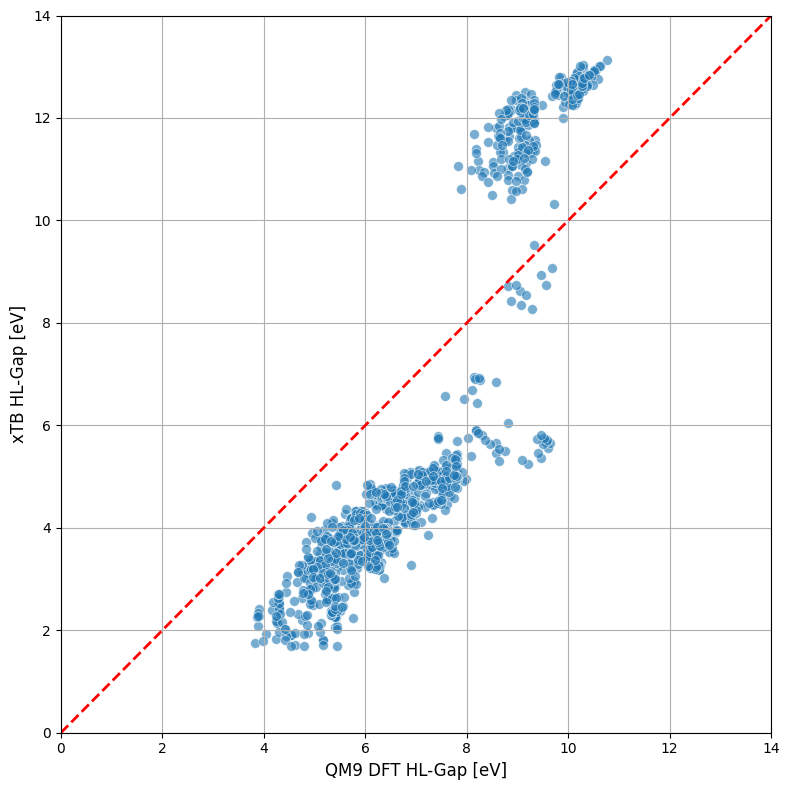

In [54]:
# Assume 'df_mixed' is your DataFrame with the overlapping data
# df_mixed contains 'gap_qm9' and 'GAP_xtb'

# --- Create the Scatter Plot ---
plt.figure(figsize=(8, 8))
plt.xlim(0,14)
plt.ylim(0,14)
plot = sns.scatterplot(
    data=df_mixed,
    x='gap_qm9',
    y='gap_xtb_predicted',
    alpha=0.6,  # Use transparency to see point density
    s=50        # Adjust marker size
)

# --- Add a 45-degree Identity Line for Comparison ---
# Find the plot limits to make the line span the entire plot
lims = [
    min(plt.gca().get_xlim()[0], plt.gca().get_ylim()[0]),
    max(plt.gca().get_xlim()[1], plt.gca().get_ylim()[1]),
]
plt.plot(lims, lims, 'r--', linewidth=2) # 'r--' creates a red dashed line

# --- Add Labels and Title ---
#plt.title('Comparison of HL-Gaps: xTB (MLPR model) vs. QM9 (B3LYP/6-31G(2df,p))', fontsize=16)
plt.xlabel('QM9 DFT HL-Gap [eV]', fontsize=12)
plt.ylabel('xTB HL-Gap [eV]', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig('xtb_modl_qm9_comparison.png',dpi=600)

<Figure size 640x480 with 0 Axes>